# NorthPeak Retail — Profitability Decline Analysis
## Python Exploratory Data Analysis & Statistical Validation

This notebook performs exploratory data analysis, statistical validation, and
visualization on top of the SQL findings in `sql/02_business_analysis.sql`.

**Purpose:** confirm the SQL findings with an independent tool, add statistical
rigor (significance testing, correlation, regression) that SQL alone doesn't
easily provide, and produce the visualizations that will inform the Power BI
dashboard design.

**Data source:** PostgreSQL `northpeak_retail` database, `northpeak` schema.


## 1. Setup & Database Connection

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

load_dotenv(find_dotenv(usecwd=True))  # finds .env at project root, from any subfolder

conn_url = URL.create(
    "postgresql+psycopg2",
    username=os.getenv("DB_USER", "northpeak_analyst"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST", "localhost"),
    port=int(os.getenv("DB_PORT", "5432")),
    database=os.getenv("DB_NAME", "northpeak_retail"),
)
engine = create_engine(conn_url)
print("Connected.")

Connected.


## 2. Load Data

We pull one wide, analysis-ready table by joining `fact_sales` to all four
dimensions. This mirrors what a Power BI star-schema model does internally,
and gives us one DataFrame to work with for the rest of the notebook.

In [16]:
query = """
SELECT
    f.sales_key, f.order_id, f.quantity, f.unit_price, f.unit_cost,
    f.discount_pct, f.sales_amount, f.cost_amount, f.profit_amount,
    d.full_date AS order_date, d.year, d.quarter, d.month, d.fiscal_quarter,
    c.customer_id, c.segment,
    p.product_name, p.category, p.sub_category,
    r.region, r.county, r.city
FROM northpeak.fact_sales f
JOIN northpeak.dim_date d ON f.order_date_key = d.date_key
JOIN northpeak.dim_customer c ON f.customer_key = c.customer_key
JOIN northpeak.dim_product p ON f.product_key = p.product_key
JOIN northpeak.dim_region r ON f.region_key = r.region_key
"""

df = pd.read_sql(query, engine)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head()

Loaded 69,735 rows, 22 columns


,sales_key,order_id,quantity,unit_price,unit_cost,discount_pct,sales_amount,cost_amount,profit_amount,order_date,...,month,fiscal_quarter,customer_id,segment,product_name,category,sub_category,region,county,city
0,1,ORD-20250518-000001,1,"23,632.89","16,545.73",0.09,"21,453.94","16,545.73","4,908.21",2025-05-18,...,5,FY25-Q2,CUST-01075,Home Office,Standing Desk,Furniture,Desks,Coast,Mombasa,Mombasa
1,2,ORD-20250518-000001,1,"2,451.90","1,661.22",0.08,"2,263.84","1,661.22",602.62,2025-05-18,...,5,FY25-Q2,CUST-01075,Home Office,USB-C Hub,Technology,Accessories,Coast,Mombasa,Mombasa
2,3,ORD-20250518-000001,1,340.49,240.54,0.11,304.60,240.54,64.06,2025-05-18,...,5,FY25-Q2,CUST-01075,Home Office,Binder Clips Box,Office Supplies,Binders,Coast,Mombasa,Mombasa
3,4,ORD-20230207-000002,5,344.35,248.88,0.12,"1,511.70","1,244.40",267.30,2023-02-07,...,2,FY23-Q1,CUST-00239,Corporate,Binder Clips Box,Office Supplies,Binders,Nairobi,Nairobi,Westlands
4,5,ORD-20230207-000002,2,"31,835.67","22,777.69",0.22,"49,720.95","45,555.38","4,165.57",2023-02-07,...,2,FY23-Q1,CUST-00239,Corporate,Tablet Air 10,Technology,Computers,Nairobi,Nairobi,Westlands


## 3. Exploratory Data Analysis (EDA)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69735 entries, 0 to 69734
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sales_key       69735 non-null  int64  
 1   order_id        69735 non-null  object 
 2   quantity        69735 non-null  int64  
 3   unit_price      69735 non-null  float64
 4   unit_cost       69735 non-null  float64
 5   discount_pct    69735 non-null  float64
 6   sales_amount    69735 non-null  float64
 7   cost_amount     69735 non-null  float64
 8   profit_amount   69735 non-null  float64
 9   order_date      69735 non-null  object 
 10  year            69735 non-null  int64  
 11  quarter         69735 non-null  int64  
 12  month           69735 non-null  int64  
 13  fiscal_quarter  69735 non-null  object 
 14  customer_id     69735 non-null  object 
 15  segment         69735 non-null  object 
 16  product_name    69735 non-null  object 
 17  category        69735 non-null 

In [18]:
df[["quantity", "unit_price", "unit_cost", "discount_pct",
    "sales_amount", "cost_amount", "profit_amount"]].describe()

,quantity,unit_price,unit_cost,discount_pct,sales_amount,cost_amount,profit_amount
count,"69,735.00","69,735.00","69,735.00","69,735.00","69,735.00","69,735.00","69,735.00"
mean,2.06,"18,749.87","13,677.01",0.12,"34,257.82","28,223.17","6,034.65"
std,1.20,"23,549.64","16,541.53",0.08,"54,404.04","42,962.45","13,006.43"
min,1.00,291.01,205.80,0.00,189.50,205.80,"-34,624.50"
25%,1.00,"1,570.86","1,106.54",0.06,"2,696.40","2,111.30",191.48
50%,2.00,"11,488.17","9,631.93",0.10,"13,906.12","13,048.45","1,224.94"
75%,3.00,"23,799.58","16,610.09",0.17,"40,391.54","32,967.32","6,674.12"
max,5.00,"94,758.82","65,686.92",0.50,"464,925.43","328,428.40","141,200.90"


In [19]:
print("Date range:", df["order_date"].min(), "to", df["order_date"].max())
print("Unique orders:", df["order_id"].nunique())
print("Unique customers:", df["customer_id"].nunique())
print("Unique products:", df["product_name"].nunique())
print()
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None — dataset is complete.")

Date range: 2023-01-01 to 2025-12-31
Unique orders: 37000
Unique customers: 1200
Unique products: 21

Missing values per column:
None — dataset is complete.


## 4. Executive Overview

Confirms the core BRD finding: overall profit margin declined from roughly
19% to roughly 12-13% over the most recent six quarters, despite sales
growing throughout the period.

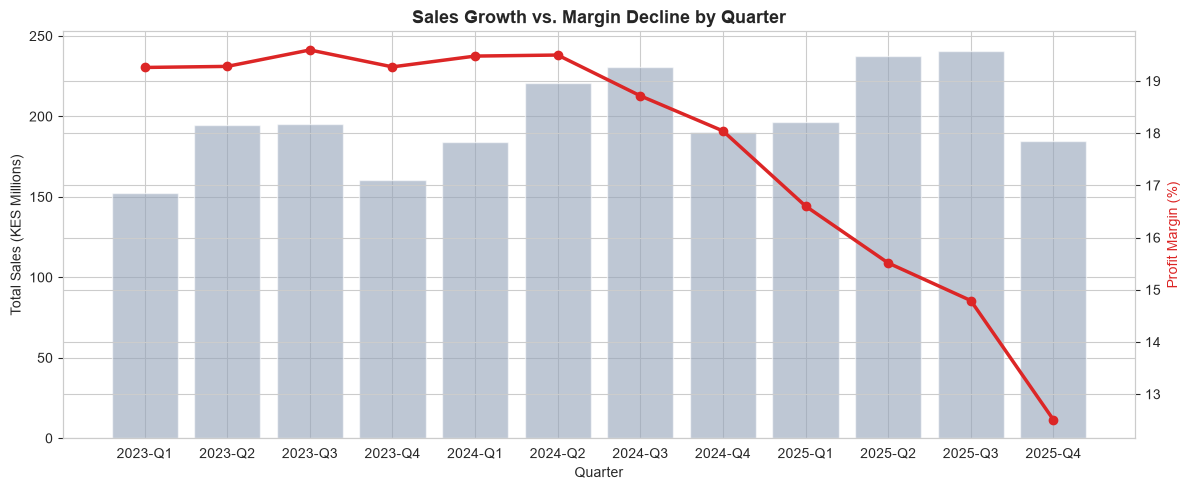

 period    total_sales  total_profit  margin_pct
2023-Q1 152,477,576.49 29,366,916.32       19.26
2023-Q2 194,701,049.65 37,538,772.12       19.28
2023-Q3 195,244,141.03 38,258,059.67       19.59
2023-Q4 160,713,661.97 30,971,062.02       19.27
2024-Q1 184,034,782.58 35,846,021.97       19.48
2024-Q2 220,860,255.07 43,062,773.99       19.50
2024-Q3 230,544,486.33 43,149,707.79       18.72
2024-Q4 190,582,871.97 34,388,413.04       18.04
2025-Q1 196,731,368.78 32,665,361.45       16.60
2025-Q2 237,446,636.89 36,836,146.73       15.51
2025-Q3 240,741,269.18 35,613,539.71       14.79
2025-Q4 184,890,631.76 23,129,293.70       12.51


In [20]:
quarterly = df.groupby(["year", "quarter"]).agg(
    total_sales=("sales_amount", "sum"),
    total_profit=("profit_amount", "sum"),
).reset_index()
quarterly["margin_pct"] = quarterly["total_profit"] / quarterly["total_sales"] * 100
quarterly["period"] = quarterly["year"].astype(str) + "-Q" + quarterly["quarter"].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(quarterly["period"], quarterly["total_sales"] / 1e6, color="#94a3b8", alpha=0.6, label="Total Sales (M)")
ax2.plot(quarterly["period"], quarterly["margin_pct"], color="#dc2626", marker="o", linewidth=2.5, label="Margin %")

ax1.set_ylabel("Total Sales (KES Millions)")
ax2.set_ylabel("Profit Margin (%)", color="#dc2626")
ax1.set_xlabel("Quarter")
ax1.set_title("Sales Growth vs. Margin Decline by Quarter")
plt.xticks(rotation=45)
fig.tight_layout()
plt.savefig("../images/margin_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print(quarterly[["period", "total_sales", "total_profit", "margin_pct"]].to_string(index=False))

## 5. Statistical Validation: Is the Margin Decline Real, or Noise?

We fit a simple linear regression of margin % against time (sequential
quarter index) to quantify the decline rate and test whether it is
statistically significant, not just visually apparent.

In [21]:
from scipy.stats import linregress

quarterly_sorted = quarterly.sort_values(["year", "quarter"]).reset_index(drop=True)
quarterly_sorted["quarter_index"] = range(len(quarterly_sorted))

slope, intercept, r_value, p_value, std_err = linregress(
    quarterly_sorted["quarter_index"], quarterly_sorted["margin_pct"]
)

print(f"Slope: {slope:.3f} percentage points per quarter")
print(f"R-squared: {r_value**2:.3f}")
print(f"P-value: {p_value:.6f}")
print()
if p_value < 0.05:
    print(f"CONCLUSION: The margin decline is statistically significant (p < 0.05).")
    print(f"On average, margin has declined by {abs(slope):.2f} percentage points per quarter.")
else:
    print("CONCLUSION: The trend is not statistically significant at the 0.05 level.")

Slope: -0.565 percentage points per quarter
R-squared: 0.762
P-value: 0.000208

CONCLUSION: The margin decline is statistically significant (p < 0.05).
On average, margin has declined by 0.57 percentage points per quarter.


## 6. Product & Category Profitability

Confirms "Tables" as a structurally negative-margin sub-category, independent
of the recent decline.

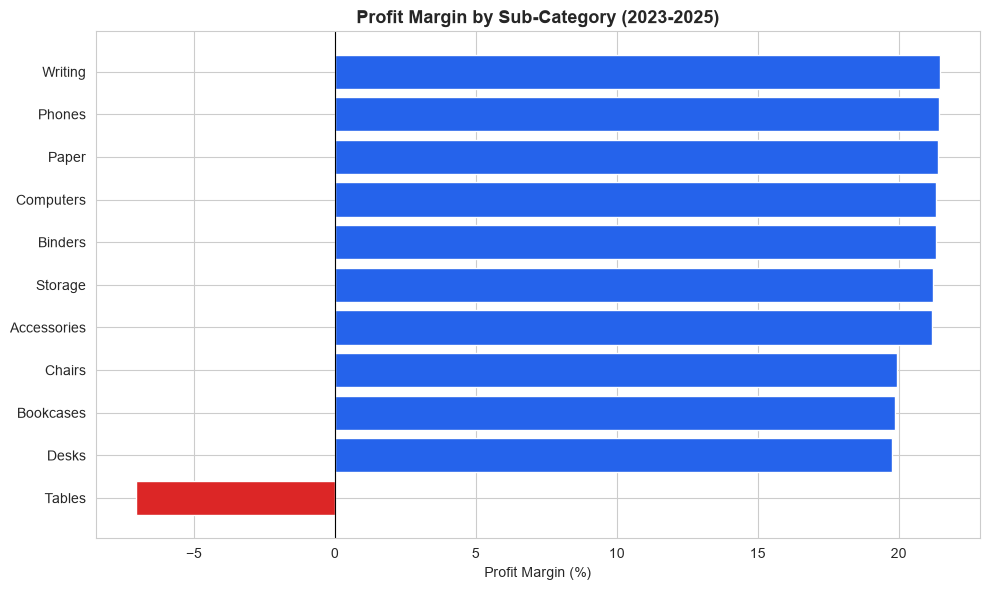

,category,sub_category,total_sales,total_profit,margin_pct
3,Furniture,Tables,"290,159,531.34","-20,490,506.14",-7.06
2,Furniture,Desks,"222,535,035.18","43,993,554.74",19.77
0,Furniture,Bookcases,"66,821,601.53","13,270,173.09",19.86
1,Furniture,Chairs,"153,667,884.43","30,623,909.66",19.93
8,Technology,Accessories,"45,202,042.87","9,581,703.39",21.20
6,Office Supplies,Storage,"9,673,947.37","2,051,605.04",21.21
4,Office Supplies,Binders,"2,157,393.56","459,668.16",21.31
9,Technology,Computers,"1,204,624,683.82","256,882,512.02",21.32
5,Office Supplies,Paper,"9,996,385.22","2,137,953.72",21.39
10,Technology,Phones,"379,399,979.06","81,300,434.60",21.43


In [22]:
subcat = df.groupby(["category", "sub_category"]).agg(
    total_sales=("sales_amount", "sum"),
    total_profit=("profit_amount", "sum"),
).reset_index()
subcat["margin_pct"] = subcat["total_profit"] / subcat["total_sales"] * 100
subcat = subcat.sort_values("margin_pct")

plt.figure(figsize=(10, 6))
colors = ["#dc2626" if m < 0 else "#2563eb" for m in subcat["margin_pct"]]
plt.barh(subcat["sub_category"], subcat["margin_pct"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Profit Margin (%)")
plt.title("Profit Margin by Sub-Category (2023-2025)")
plt.tight_layout()
plt.savefig("../images/subcategory_margin.png", dpi=150, bbox_inches="tight")
plt.show()

subcat

## 7. Discount Analysis: Correlation & Regression

Tests whether discount level is statistically associated with lower margin,
and quantifies the relationship using linear regression on order-level data.

Correlation (discount % vs. margin %): r = -0.652, p = 0.000000



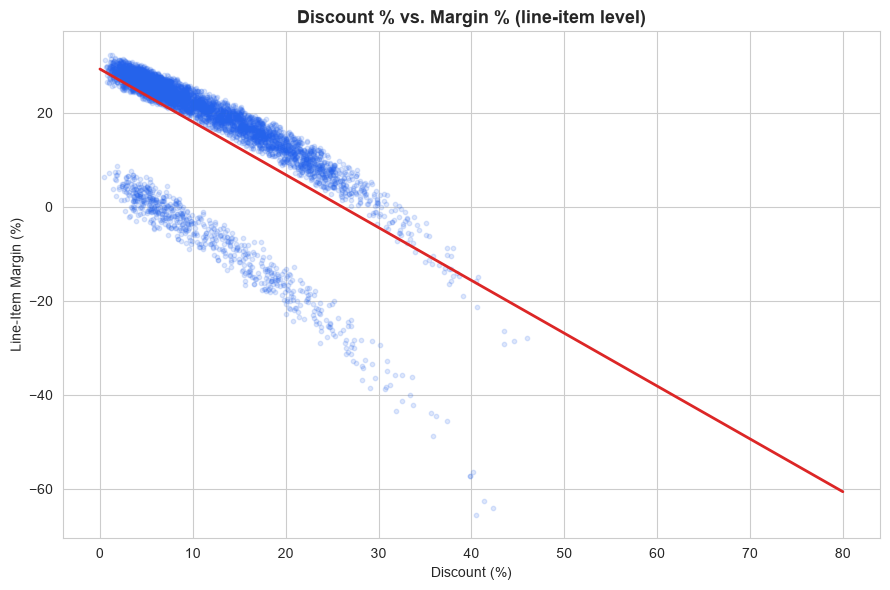

In [23]:
line_margin_pct_all = df["profit_amount"] / df["sales_amount"] * 100
corr, corr_p = stats.pearsonr(df["discount_pct"], line_margin_pct_all)
print(f"Correlation (discount % vs. margin %): r = {corr:.3f}, p = {corr_p:.6f}")
print()

sample = df.sample(min(5000, len(df)), random_state=42)  # sample for plot clarity
sample_margin = sample["profit_amount"] / sample["sales_amount"] * 100

plt.figure(figsize=(9, 6))
plt.scatter(sample["discount_pct"] * 100, sample_margin, alpha=0.15, s=10, color="#2563eb")
z = np.polyfit(df["discount_pct"] * 100, line_margin_pct_all, 1)
x_line = np.linspace(0, 80, 100)
plt.plot(x_line, np.poly1d(z)(x_line), color="#dc2626", linewidth=2)
plt.xlabel("Discount (%)")
plt.ylabel("Line-Item Margin (%)")
plt.title("Discount % vs. Margin % (line-item level)")
plt.tight_layout()
plt.savefig("../images/discount_vs_margin.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Regional Performance

Confirms Nairobi as the lowest-margin region in the most recent year.

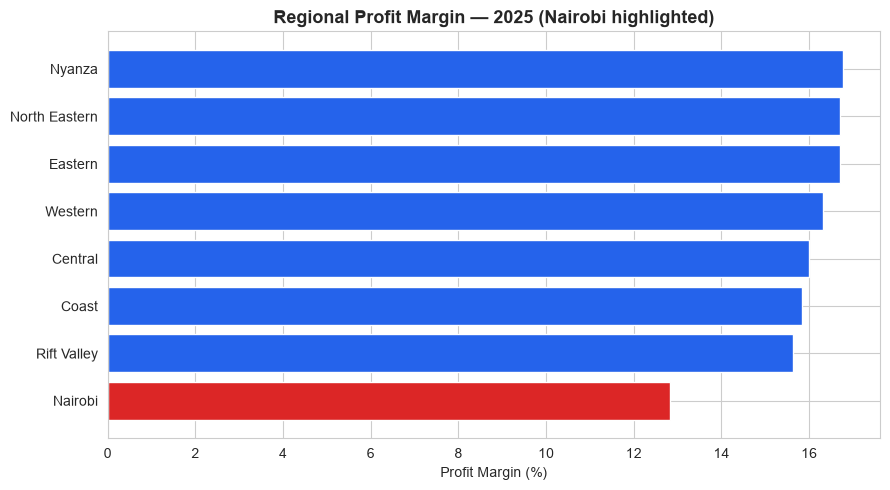

,region,total_sales,total_profit,margin_pct
3,Nairobi,"323,665,839.40","41,533,358.56",12.83
6,Rift Valley,"97,546,829.57","15,245,507.37",15.63
1,Coast,"108,686,570.91","17,222,466.90",15.85
0,Central,"109,470,077.31","17,502,626.30",15.99
7,Western,"38,857,072.98","6,342,985.64",16.32
2,Eastern,"64,986,596.87","10,853,583.31",16.70
4,North Eastern,"25,345,186.74","4,234,851.27",16.71
5,Nyanza,"91,251,732.83","15,308,962.24",16.78


In [24]:
region_2025 = df[df["year"] == 2025].groupby("region").agg(
    total_sales=("sales_amount", "sum"),
    total_profit=("profit_amount", "sum"),
).reset_index()
region_2025["margin_pct"] = region_2025["total_profit"] / region_2025["total_sales"] * 100
region_2025 = region_2025.sort_values("margin_pct")

plt.figure(figsize=(9, 5))
colors = ["#dc2626" if r == "Nairobi" else "#2563eb" for r in region_2025["region"]]
plt.barh(region_2025["region"], region_2025["margin_pct"], color=colors)
plt.xlabel("Profit Margin (%)")
plt.title("Regional Profit Margin — 2025 (Nairobi highlighted)")
plt.tight_layout()
plt.savefig("../images/regional_margin_2025.png", dpi=150, bbox_inches="tight")
plt.show()

region_2025

## 9. Customer Segment Analysis: The Dilution Effect

Statistical test: is Corporate's margin significantly different from other
segments, and has the gap widened over time?

In [25]:
df["line_margin_pct"] = df["profit_amount"] / df["sales_amount"] * 100

corp_2025 = df[(df["segment"] == "Corporate") & (df["year"] == 2025)]["line_margin_pct"]
other_2025 = df[(df["segment"] != "Corporate") & (df["year"] == 2025)]["line_margin_pct"]

t_stat, t_p = stats.ttest_ind(corp_2025, other_2025, equal_var=False)
print(f"2025 Corporate mean line margin: {corp_2025.mean():.2f}%")
print(f"2025 All-other-segments mean line margin: {other_2025.mean():.2f}%")
print(f"Welch's t-test: t = {t_stat:.2f}, p = {t_p:.6f}")
if t_p < 0.05:
    print("CONCLUSION: Corporate's margin is statistically significantly lower than other segments in 2025.")

2025 Corporate mean line margin: 2.96%
2025 All-other-segments mean line margin: 18.80%
Welch's t-test: t = -88.44, p = 0.000000
CONCLUSION: Corporate's margin is statistically significantly lower than other segments in 2025.


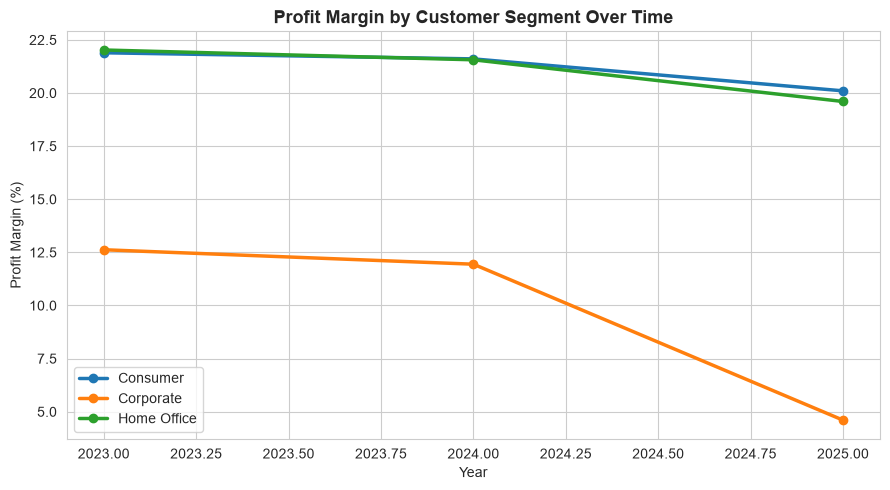

In [26]:
segment_yearly = df.groupby(["year", "segment"]).agg(
    total_sales=("sales_amount", "sum"),
    total_profit=("profit_amount", "sum"),
).reset_index()
segment_yearly["margin_pct"] = segment_yearly["total_profit"] / segment_yearly["total_sales"] * 100

plt.figure(figsize=(9, 5))
for seg in segment_yearly["segment"].unique():
    sub = segment_yearly[segment_yearly["segment"] == seg]
    plt.plot(sub["year"], sub["margin_pct"], marker="o", linewidth=2.5, label=seg)
plt.xlabel("Year")
plt.ylabel("Profit Margin (%)")
plt.title("Profit Margin by Customer Segment Over Time")
plt.legend()
plt.tight_layout()
plt.savefig("../images/segment_margin_trend.png", dpi=150, bbox_inches="tight")
plt.show()

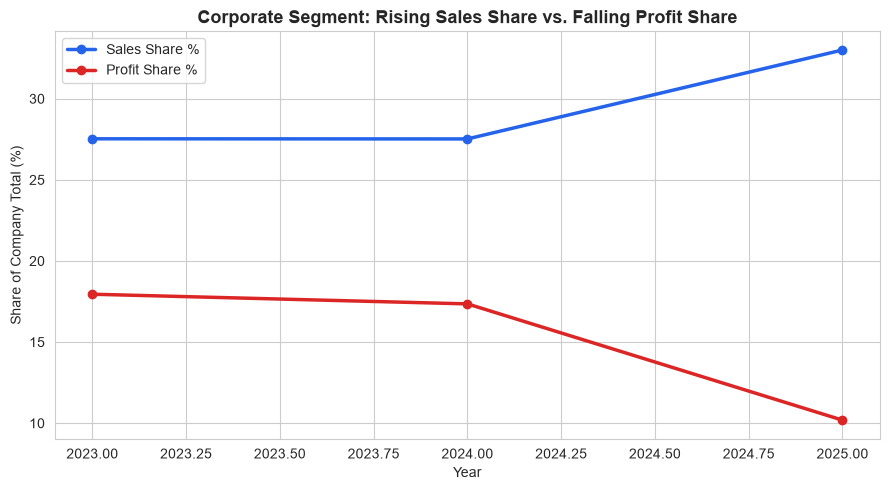

,year,sales_share,profit_share
1,2023,27.53,17.95
4,2024,27.52,17.35
7,2025,33.00,10.19


In [27]:
year_totals = df.groupby("year")[["sales_amount", "profit_amount"]].sum()
segment_yearly["sales_share"] = segment_yearly.apply(
    lambda r: r["total_sales"] / year_totals.loc[r["year"], "sales_amount"] * 100, axis=1
)
segment_yearly["profit_share"] = segment_yearly.apply(
    lambda r: r["total_profit"] / year_totals.loc[r["year"], "profit_amount"] * 100, axis=1
)

corp = segment_yearly[segment_yearly["segment"] == "Corporate"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(corp["year"], corp["sales_share"], marker="o", linewidth=2.5, label="Sales Share %", color="#2563eb")
ax.plot(corp["year"], corp["profit_share"], marker="o", linewidth=2.5, label="Profit Share %", color="#dc2626")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Company Total (%)")
ax.set_title("Corporate Segment: Rising Sales Share vs. Falling Profit Share")
ax.legend()
plt.tight_layout()
plt.savefig("../images/corporate_dilution.png", dpi=150, bbox_inches="tight")
plt.show()

corp[["year", "sales_share", "profit_share"]]

## 10. Key Findings Summary

This section consolidates the statistically-validated findings for use in the
Executive Summary and Business Recommendations documents.

In [28]:
print("=" * 70)
print("KEY FINDINGS — STATISTICALLY VALIDATED")
print("=" * 70)
print(f"""
1. MARGIN DECLINE IS REAL AND SIGNIFICANT
   - Linear regression: margin declining at {abs(slope):.2f} pp/quarter (p = {p_value:.4f})
   - Overall margin fell from ~{quarterly_sorted['margin_pct'].iloc[0]:.1f}% (2023 Q1)
     to ~{quarterly_sorted['margin_pct'].iloc[-1]:.1f}% (2025 Q4)

2. DISCOUNT LEVEL IS SIGNIFICANTLY CORRELATED WITH LOWER MARGIN
   - Correlation: r = {corr:.2f} (p = {corr_p:.4f})

3. CORPORATE SEGMENT MARGIN IS SIGNIFICANTLY LOWER AND WIDENING
   - 2025 Corporate margin ({corp_2025.mean():.1f}%) vs. other segments ({other_2025.mean():.1f}%)
   - Statistically significant gap (Welch's t-test, p = {t_p:.4f})
   - Corporate's sales share is RISING while its profit share is FALLING —
     a volume/margin dilution pattern

4. NAIROBI IS THE LOWEST-MARGIN REGION IN 2025
   - {region_2025.iloc[0]['region']}: {region_2025.iloc[0]['margin_pct']:.1f}% margin
     vs. company average

5. "TABLES" SUB-CATEGORY IS STRUCTURALLY UNPROFITABLE
   - Margin: {subcat[subcat['sub_category']=='Tables']['margin_pct'].values[0]:.1f}%
   - This is a permanent issue, not related to the recent decline
""")

KEY FINDINGS — STATISTICALLY VALIDATED

1. MARGIN DECLINE IS REAL AND SIGNIFICANT
   - Linear regression: margin declining at 0.57 pp/quarter (p = 0.0002)
   - Overall margin fell from ~19.3% (2023 Q1)
     to ~12.5% (2025 Q4)

2. DISCOUNT LEVEL IS SIGNIFICANTLY CORRELATED WITH LOWER MARGIN
   - Correlation: r = -0.65 (p = 0.0000)

3. CORPORATE SEGMENT MARGIN IS SIGNIFICANTLY LOWER AND WIDENING
   - 2025 Corporate margin (3.0%) vs. other segments (18.8%)
   - Statistically significant gap (Welch's t-test, p = 0.0000)
   - Corporate's sales share is RISING while its profit share is FALLING —
     a volume/margin dilution pattern

4. NAIROBI IS THE LOWEST-MARGIN REGION IN 2025
   - Nairobi: 12.8% margin
     vs. company average

5. "TABLES" SUB-CATEGORY IS STRUCTURALLY UNPROFITABLE
   - Margin: -7.1%
   - This is a permanent issue, not related to the recent decline

